# Задание 1.

Поработаем с датасетом Black Friday. Есть его описание:

Description

The dataset here is a sample of the transactions made in a retail store. The store wants to know better the customer purchase behaviour against different products. Specifically, here the problem is a regression problem where we are trying to predict the dependent variable (the amount of purchase) with the help of the information contained in the other variables.

Classification problem can also be settled in this dataset since several variables are categorical, and some other approaches could be "Predicting the age of the consumer" or even "Predict the category of goods bought". This dataset is also particularly convenient for clustering and maybe find different clusters of consumers within it.

In [142]:
import pandas as pd
import numpy as np
from matplotlib import pylab as plt

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [143]:
data = pd.read_csv('BlackFriday.csv')
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


# Подготовка данных

In [144]:
missing_values = data.isnull().sum().sort_values(ascending = False)
missing_values = missing_values[missing_values > 0]/data.shape[0]
print(f'{missing_values *100} %')

Product_Category_3    69.441029
Product_Category_2    31.062713
dtype: float64 %


Скорее всего NaN-ы в Product_Category_2 и Product_Category_3 означают, что человек не покупал продукты из этих категорий.

Поэтому можем заменить эти пропущенные значения на 0.

In [145]:
data = data.fillna(0)

In [146]:
data.shape

(537577, 12)

In [147]:
missing_values = data.isnull().sum().sort_values(ascending = False)
missing_values = missing_values[missing_values > 0] / data.shape[0]
print(f'{missing_values * 100} %')

Series([], dtype: float64) %


Посмотрим, какие типы данных есть в нашем датасете. 

Выведите на экран тип каждой колонки в таблице.

In [148]:
data.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Обработаем нечисловые колонки.

1) Выведите на экран все возможные значения из столбца Gender.

2) Замените значение 'M' на 1, а 'F' на 0.

In [149]:
data['Gender'] = data['Gender'].apply(lambda x: 1 if x == 'M' else 0)
data['Gender']

0         0
1         0
2         0
3         0
4         1
         ..
537572    1
537573    1
537574    1
537575    1
537576    1
Name: Gender, Length: 537577, dtype: int64

Поработаем со столбцом Age.

1) Выведите на экран все возможные значения из столбца Age.

2) Напишите функцию для перевода каждого диапазона возрастов в число (самые маленькие возрасты - 0, следующий диапазон - 1 и т.д.). Замените значения в столбце Age на числовые, применив эту функцию.

In [150]:
data['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [151]:
data[data['Age'].isna()]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase


In [152]:
#your code here

def map_age(age):
    #print(age)
    if age == '0-17':
        return 1
    elif age == '18-25':
        return 2
    elif age == '26-35':
        return 3
    elif age == '36-45':
        return 4
    elif age == '46-50':
        return 5
    elif age == '55+':
        return 6
    
data['Age'] = data['Age'].map(map_age)
data[14:19]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
14,1000006,P00231342,0,NaN,9,A,1,0,5,8.0,14.0,5378
15,1000006,P00190242,0,NaN,9,A,1,0,4,5.0,0.0,2079
16,1000006,P0096642,0,NaN,9,A,1,0,2,3.0,4.0,13055
17,1000006,P00058442,0,NaN,9,A,1,0,5,14.0,0.0,8851
18,1000007,P00036842,1,4.0,1,B,1,1,1,14.0,16.0,11788


In [153]:
data = data.dropna()
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,1.0,10,A,2,0,3,0.0,0.0,8370
1,1000001,P00248942,0,1.0,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,0,1.0,10,A,2,0,12,0.0,0.0,1422
3,1000001,P00085442,0,1.0,10,A,2,0,12,14.0,0.0,1057
4,1000002,P00285442,1,6.0,16,C,4+,0,8,0.0,0.0,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,1,4.0,16,C,1,0,1,2.0,0.0,11664
537573,1004737,P00111142,1,4.0,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,1,4.0,16,C,1,0,8,15.0,0.0,8043
537575,1004737,P00285842,1,4.0,16,C,1,0,5,0.0,0.0,7172


Обработаем столбец City_Category.

1) Выведите все уникальные значения данного столбца.

2) Закодируйте столбец с помощью OneHotEncoding (get_dummies).

In [154]:
data['City_Category'].unique()
data = pd.get_dummies(data=data, columns=['City_Category'], drop_first=True)

In [155]:
data

,User_ID,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,1000001,P00069042,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,1000001,P00248942,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,1000001,P00087842,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,1000001,P00085442,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1000002,P00285442,1,6.0,16,4+,0,8,0.0,0.0,7969,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,1,4.0,16,1,0,1,2.0,0.0,11664,False,True
537573,1004737,P00111142,1,4.0,16,1,0,1,15.0,16.0,19196,False,True
537574,1004737,P00345942,1,4.0,16,1,0,8,15.0,0.0,8043,False,True
537575,1004737,P00285842,1,4.0,16,1,0,5,0.0,0.0,7172,False,True


Наконец, обработаем Stay_In_Current_City_Years.

1) Выведите на экран все уникальные значения данного столбца.

2) Замените '4+' на 4, а все остальные значения оставьте как есть, но переведите их в числовой вид (x -> int(x)).

In [156]:
#your code here

def map_stay(years):
    if years == '4+':
        return 4
    else:
        return int(years)
    
data['Stay_In_Current_City_Years'] = data['Stay_In_Current_City_Years'].apply(map_stay)

In [157]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,1000001,P00069042,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,1000001,P00248942,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,1000001,P00087842,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,1000001,P00085442,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1000002,P00285442,1,6.0,16,4,0,8,0.0,0.0,7969,False,True


Удалим столбцы User_ID и Product_ID.

In [158]:
data.drop(columns=['User_ID', 'Product_ID'], axis=1, inplace=True)

In [159]:
data.head()

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,0,1.0,10,2,0,3,0.0,0.0,8370,False,False
1,0,1.0,10,2,0,1,6.0,14.0,15200,False,False
2,0,1.0,10,2,0,12,0.0,0.0,1422,False,False
3,0,1.0,10,2,0,12,14.0,0.0,1057,False,False
4,1,6.0,16,4,0,8,0.0,0.0,7969,False,True


# Исследование данных

1. Как влияет пол на целевую переменную Purchase? Постройте диаграмму.

2. Как влияет возраст на целевую переменную Purchase? Постройте диаграмму.

3. Как влияет City_Category на целевую переменную Purchase? Постройте диаграмму для каждой закодированной категории.

Gender


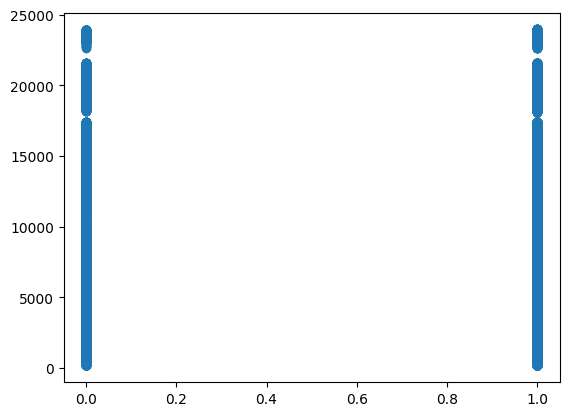

Age


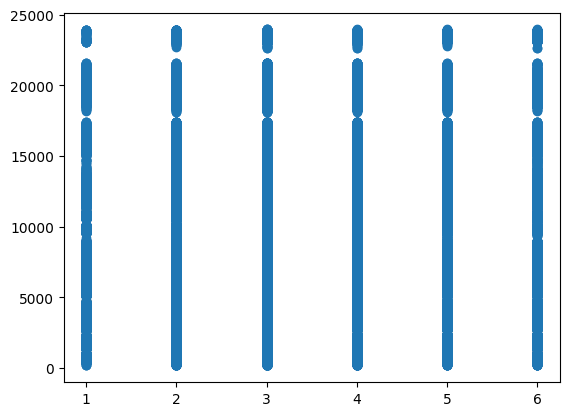

City_Category_B


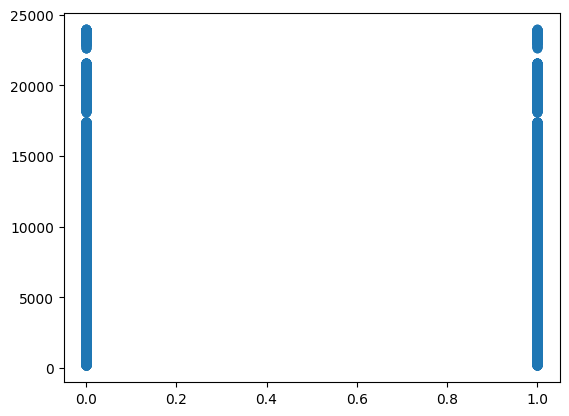

City_Category_C


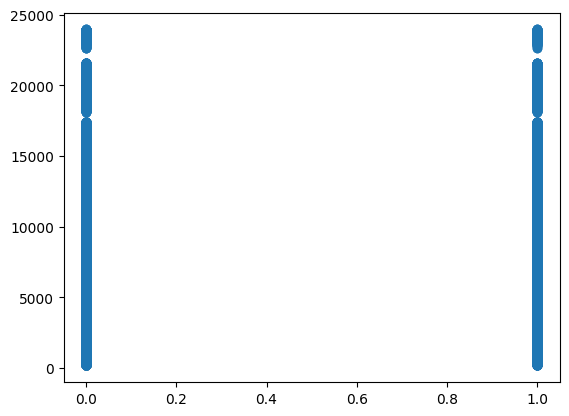

In [160]:
cs = ['Gender', 'Age', 'City_Category_B', 'City_Category_C']
for c in cs:
    print(c)
    plt.scatter(data[c], data['Purchase'])
    plt.show()

In [161]:
#your code here

In [162]:
import seaborn as sns

Нарисуйте матрицу корреляций признаков.

<Axes: >

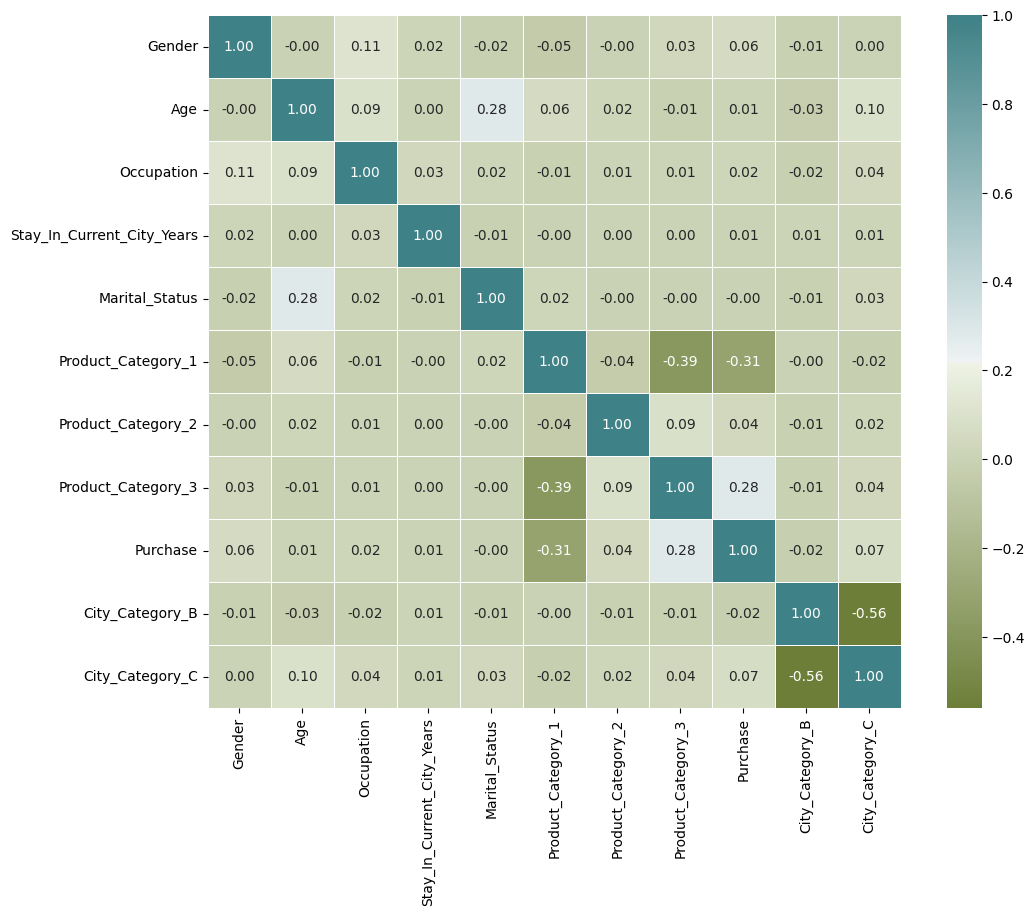

In [163]:
plt.figure(figsize=(12, 9))
corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)
#your code here

# Построение модели

Применим к нашим данным масштабирование: для того, чтобы модель лучше училась, будет неплохо привести все признаки к одному масштабу, иначе могут возникнуть проблемы с коэффициентами: если какой-то признак принимает очень большие значения, а другой - маленькие, модели будет сложно корректно подобрать веса. 

Стандартная формула для масштабирования:

$\hat{x} = \frac{x - \mu}{\sigma}$

In [164]:
X = data.drop(['Purchase'], axis=1)

y = data['Purchase']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)
print(ypred_test)

[12099.21693063  4731.81919419  8468.1928964  ...  8806.88339308
 11039.8159742   8802.12091694]


In [165]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.13574965133425987, 0.13535392963431603)

In [166]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,Gender,214.020565
1,Age,111.196468
2,Occupation,20.532482
3,Stay_In_Current_City_Years,16.621582
4,Marital_Status,-22.104269
5,Product_Category_1,-1189.695358
6,Product_Category_2,53.056457
7,Product_Category_3,930.305634
8,City_Category_B,73.282145
9,City_Category_C,310.384221


In [167]:
#plt(regressor.coef_)

Добавим L1 регуляризацию.

In [168]:
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: 0.13526335158343972 21401976.460942455
[  205.50411498    99.15193565    13.42166051     7.60304424
    -8.54699251 -1182.69862537    44.37868112   924.82152447
    51.33669333   289.75313143] 



Посмотрим, что происходит при разных значениях параметра регуляризации $\alpha$

In [169]:
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

alpha=0.1
Scores: 0.13535347632439831 21399745.900241602
[  213.93531486   111.07618892    20.46141684    16.53149756
   -21.9686917  -1189.62537884    52.96968104   930.25089362
    73.06063443   310.17673436] 

alpha=25.1
Scores: 0.13498132963760456 21408956.420745574
[  192.37249552    84.35131467     2.38110159     0.
    -0.         -1172.13895531    31.20453574   916.50516125
    18.07933621   258.52973058] 

alpha=50.1
Scores: 0.1344765000177326 21421450.804626573
[  168.7635833     61.33863383     0.             0.
    -0.         -1154.09424557     9.11823328   902.27648787
     0.           227.09547997] 

alpha=75.1
Scores: 0.1338997543405801 21435725.089669276
[  145.14858164    37.3617229      0.             0.
    -0.         -1135.71212715     0.           886.70905635
     0.           205.59415638] 



**Видим, что L1-регуляризация зануляет некоторые веса и таким образом производит отбор признаков.**

Подберем оптимальное значение параметра регуляризации по кросс-валидации

In [170]:
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [171]:
lasso_cv.coef_

array([ 488.96518107,  100.78627107,    4.0147052 ,   11.65109025,
        -43.92269567, -318.71670659,    9.29888689,  148.01687317,
        154.17790032,  685.7795791 ])

In [172]:
lasso_cv.alpha_

0.1

Обучим модель с найденным параметром регуляризации $\alpha$

In [173]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train), mean_squared_error(ytest,ypred2_test))

Scores: 0.13574964670713352 0.13535347632439831 21404257.42714373 21399745.900241602


Добавим L2 регуляризацию.

In [174]:
from sklearn.linear_model import Ridge

for a in np.arange(0.0,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.0
Scores: 0.13535392963431603 21399734.68095512
[  214.020565     111.19646846    20.53248246    16.62158227
   -22.10426874 -1189.69535827    53.05645678   930.30563389
    73.28214478   310.38422061]
alpha=2.5
Scores: 0.13535392860197326 21399734.7065053
[  214.01959189   111.1954889     20.5327184     16.62155359
   -22.10393805 -1189.68927868    53.05673325   930.30227275
    73.28010733   310.38146481]
alpha=5.0
Scores: 0.13535392756381281 21399734.732199464
[  214.01861878   111.19450936    20.53295433    16.62152491
   -22.10360738 -1189.68319917    53.0570097    930.29891163
    73.27806994   310.37870907]
alpha=7.5
Scores: 0.1353539265198347 21399734.75803761
[  214.01764569   111.19352983    20.53319026    16.62149623
   -22.10327671 -1189.67711972    53.05728616   930.29555051
    73.27603262   310.3759534 ]
alpha=10.0
Scores: 0.13535392547003933 21399734.78401974
[  214.0166726    111.19255031    20.53342617    16.62146755
   -22.10294605 -1189.67104035    53.057562

**Ridge регрессия не зануляет веса (они могут быть очень маленькими, но ненулевыми).**

Теперь подберем оптимальное a по кросс-валидации.

In [175]:
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(-2, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

KeyboardInterrupt: 

In [35]:
ridge_cv.alpha_

95.47716114208056

In [36]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.13390342733508676 0.13331752022508214


Добавим одновременно и L1, и L2 регуляризацию.

У ElasticNet два параметра: alpha и l1_ratio. Используйте ElasticNet со значениями параметров alpha и l1_ratio равными 0.5.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

In [18]:
from sklearn.linear_model import ElasticNet

In [38]:
X

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,City_Category_B,City_Category_C
0,0,1.0,10,2,0,3,0.0,0.0,False,False
1,0,1.0,10,2,0,1,6.0,14.0,False,False
2,0,1.0,10,2,0,12,0.0,0.0,False,False
3,0,1.0,10,2,0,12,14.0,0.0,False,False
4,1,6.0,16,4,0,8,0.0,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...
537572,1,4.0,16,1,0,1,2.0,0.0,False,True
537573,1,4.0,16,1,0,1,15.0,16.0,False,True
537574,1,4.0,16,1,0,8,15.0,0.0,False,True
537575,1,4.0,16,1,0,5,0.0,0.0,False,True


In [39]:
regr = ElasticNet(random_state=0)
regr.fit(X, y)
ElasticNet(random_state=0)
print(regr.coef_)
print(regr.intercept_)
print(regr.predict([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

[ 130.03536518   77.32381106    8.23483441   12.16236546   -6.87494744
 -309.19477713    9.81814032  150.3169855   -38.05713875  169.85081369]
9820.063546877851
[9820.06354688]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


### Посмотрим на веса, которые присвоила линейная регрессия признакам (regressor.coef_).

In [40]:
#your code here
regressor3.coef_

array([  125.94754012,    17.68450152,     0.        ,     0.        ,
           0.        , -1120.68226706,     0.        ,   873.35698664,
           0.        ,   187.95976516])

Можно записать эти веса в таблицу рядом с названиями признаков (для удобства).

In [41]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor3.coef_))], axis = 1)
coefficients

,0,0
0,Gender,125.947540
1,Age,17.684502
2,Occupation,0.000000
3,Stay_In_Current_City_Years,0.000000
4,Marital_Status,0.000000
5,Product_Category_1,-1120.682267
6,Product_Category_2,0.000000
7,Product_Category_3,873.356987
8,City_Category_B,0.000000
9,City_Category_C,187.959765


In [42]:
len(data),len(Xtest)

(499959, 99992)

# Задание 2

Поработайте с датасетом affairs. Предскажите значение в колонке affairs по остальным факторам.

1. Сначала проведите разведочный анализ, а именно, исследуйте зависимость таргета от каждого фактора (или пары факторов).

2. Обучите линейную регрессию, посмотрите на качество на кросс-валидации, затем разбейте данные на train и test,
обучите алгоритм на train и сделайте предсказания на train и test, выведите ошибки.

3. Посмотрите на матрицу корреляций факторов и целевой переменной. 
Если есть пары сильно коррелирующих между собой факторов, удалите один из пары.

Если есть факторы, слабо коррелирующие с таргетом, удалите их.

Заново обучите алгоритм на обновленных данных. Как изменилось его качество?

In [286]:
affairs = pd.read_csv('affairs.csv')
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [287]:
affairs.isnull().sum()

rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

In [288]:
affairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


In [289]:
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict

<Axes: >

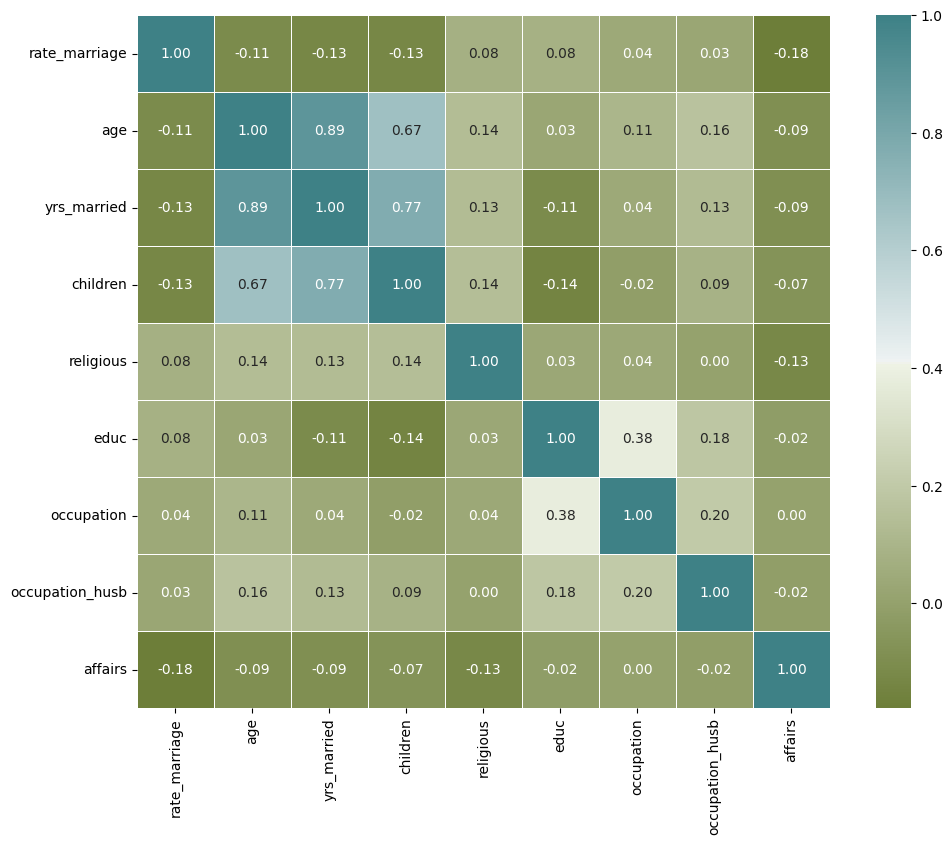

In [290]:
#1. Сначала проведите разведочный анализ, а именно, исследуйте зависимость таргета от каждого фактора (или пары факторов).
plt.figure(figsize=(12,9))

corr = affairs.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)
#ожидаем зануление образования, профессии мужа и рода деятельности

In [291]:
#for c in affairs.columns:
 #   if c != 'affairs':
  #      print(c)
   #     plt.scatter(affairs[c], affairs['affairs'])
    #    plt.show()

In [292]:
#2. Обучите линейную регрессию, посмотрите на качество на кросс-валидации, затем разбейте данные на train и test,
#обучите алгоритм на train и сделайте предсказания на train и test, выведите ошибки.
X = affairs.drop(['affairs'], axis=1)
y = affairs['affairs']
lasso = linear_model.Lasso()
y_pred = cross_val_predict(lasso, X, y, cv=5)

In [293]:
y_pred

array([0.32500696, 0.32500696, 0.32500696, ..., 0.99613001, 0.92943664,
       0.99613001])

In [294]:
n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=5, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=5, random_state=17)

In [295]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=17)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor2 = Lasso(alpha=lasso_cv.alpha_)
regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)


print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train), mean_squared_error(ytest,ypred2_test))

Scores: 0.052253463308564396 0.0354812899991509 4.4226078458627 5.401510918363273


In [296]:
trainMSE = mean_squared_error(ytrain,ypred2_train) ** 0.5
testMSE = mean_squared_error(ytest,ypred2_test) ** 0.5
print(trainMSE, testMSE)

2.1029997255973907 2.3241150828569728


In [297]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor2.coef_))], axis = 1)
coefficients

,0,0
0,rate_marriage,-0.301714
1,age,-0.087002
2,yrs_married,-0.041427
3,children,-0.000000
4,religious,-0.139274
5,educ,-0.000000
6,occupation,0.000000
7,occupation_husb,-0.000000


In [298]:
#3. Посмотрите на матрицу корреляций факторов и целевой переменной. 
#Если есть пары сильно коррелирующих между собой факторов, удалите один из пары.

#Если есть факторы, слабо коррелирующие с таргетом, удалите их.

#Заново обучите алгоритм на обновленных данных. Как изменилось его качество?
affairs2 = affairs.copy()
affairs2.drop(['occupation', 'occupation_husb', 'educ'], axis=1, inplace=True) #удаляем слабо коррелирующие
affairs2.drop(['yrs_married'], axis=1, inplace=True) #удаляем сильно коррелирующие между собой: года коррелируют с детьми и возрасторм
affairs2

,rate_marriage,age,children,religious,affairs
0,3.0,32.0,3.0,3.0,0.111111
1,3.0,27.0,3.0,1.0,3.230769
2,4.0,22.0,0.0,1.0,1.400000
3,4.0,37.0,4.0,3.0,0.727273
4,5.0,27.0,1.0,1.0,4.666666
...,...,...,...,...,...
6361,5.0,32.0,2.0,3.0,0.000000
6362,4.0,32.0,1.0,1.0,0.000000
6363,5.0,22.0,0.0,2.0,0.000000
6364,5.0,32.0,1.0,3.0,0.000000


In [299]:
X2 = affairs2.drop(['affairs'], axis=1)
y2 = affairs2['affairs']
n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, max_iter=1000,
                   cv=5, random_state=17)
lasso_cv.fit(X2, y2)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=5, random_state=17)

In [300]:
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(X2, y2, test_size=0.2, random_state=17)

scaler = StandardScaler().fit(Xtrain2)
Xtrain2 = scaler.transform(Xtrain2)
Xtest2 = scaler.transform(Xtest2)

regressor2 = Lasso(alpha=lasso_cv.alpha_)
regressor2.fit(Xtrain2, ytrain2)

ypred22_train = regressor2.predict(Xtrain2)
ypred22_test = regressor2.predict(Xtest2)


print('Scores:', r2_score(ytrain,ypred22_train), r2_score(ytest,ypred22_test), mean_squared_error(ytrain,ypred22_train), mean_squared_error(ytest,ypred22_test))

Scores: 0.05196568940735036 0.034908121179899054 4.4239507271754475 5.404720786251943


In [301]:
#со старыми: 0.052253463308564396 0.0354812899991509 4.4226078458627 5.401510918363273
#c обновленными: 0.05196568940735036 0.034908121179899054 4.4239507271754475 5.404720786251943
coefficients = pd.concat([pd.DataFrame(X2.columns),pd.DataFrame(np.transpose(regressor2.coef_))], axis = 1)
coefficients

,0,0
0,rate_marriage,-0.300502
1,age,-0.122678
2,children,-0.001488
3,religious,-0.139797


# Задание 3. 

Поработайте с датасетом House Sales in King County. Обратите внимание, что не все признаки в датасете полезны. Целевая переменная - очевидно, price. 

In [302]:
housedata = pd.read_csv('kc_house_data.csv')
housedata.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [303]:
housedata.info() #все колонки заполнены

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [304]:
housedata['date'] = housedata['date'].apply(lambda x: int(x.replace('T000000', '')))

In [305]:
housedata

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


<Axes: >

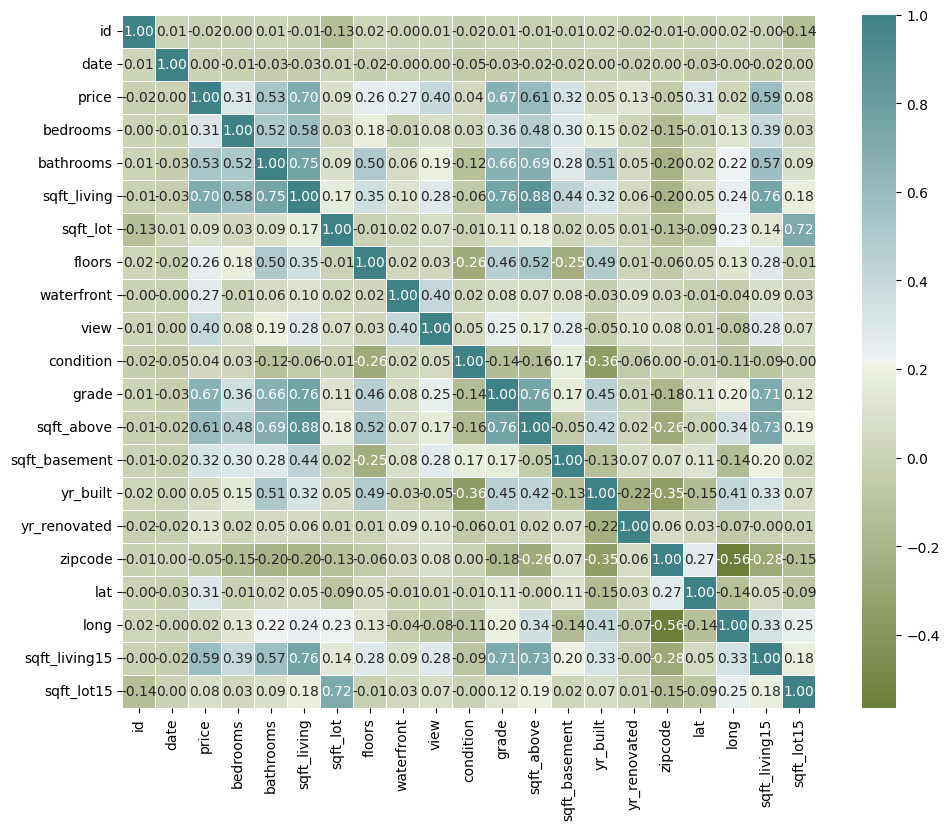

In [306]:
plt.figure(figsize=(12,9))

corr = housedata.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)
#есть признаки, мало коррелирующие с целевой переменной. попробуем добавить оегуляризацию и отсеять ненужные

In [307]:
#for c in housedata.columns:
 #   if c != 'price':
  #      print(c)
   ##    plt.show()

In [308]:
housedata.drop(['id', 'date'], axis=1, inplace=True)
housedata.drop(['sqft_living15', 'sqft_lot15', 'sqft_above'], axis=1, inplace=True)

In [309]:
#разбиваем данные на тест и трейн
X = housedata.drop(['price'], axis=1)
y = housedata['price']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=42)
scaler = StandardScaler().fit(X)
Xtrain, Xtest = scaler.transform(Xtrain), scaler.transform(Xtest)

In [310]:
#добавляем регуляризации
#посмотрим на оптимальный коэффициент и обучим с ним
bestmse = 100000000000
bestr2 = 0
for a in np.arange(0.0, 0.5, 0.1):
    regressor = ElasticNet(alpha=a, random_state=42)
    regressor.fit(Xtrain, ytrain)
    ypred = regressor.predict(Xtest)
    if mean_squared_error(ytest,ypred) < bestmse:
        bestmse = mean_squared_error(ytest,ypred)
    if r2_score(ytest,ypred) > bestr2:
        bestr2 = r2_score(ytest,ypred)
    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred), mean_squared_error(ytest,ypred))
    print(bestr2, bestmse)
regressor = ElasticNet(alpha=0.1, random_state=42)
regressor.fit(Xtrain, ytrain)
#коэфифциенты a говорят, что лучше использовать линейную регрессию
#без удаления столбцов ['condition', 'yr_built', 'zipcode', 'long']: 0.7061296014767043 43959374772.734604
#с удалением: Scores: 0.6572976193872431 51264034964.27794
#c удалением даты и айди: 0.704846607776173 44151294752.41313
#видимо важны все признаки, эластик нет тоже ничего не занижает
#с удалением одного из признаков: с удалением sqft lot 15 и sqft living 15, sqft above и не удалением остальных: 0.7048982582801718 44143568476.22508
#с удалением всего 0.7036361064377242 44332370771.866486

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.191e+14, tolerance: 2.104e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using

alpha=0.0
Scores: 0.7036361064377242 44332370771.866486
0.7036361064377242 44332370771.866486
alpha=0.1
Scores: 0.7001608894269808 44852220228.496056
0.7036361064377242 44332370771.866486
alpha=0.2
Scores: 0.6952689159365104 45583998921.16634
0.7036361064377242 44332370771.866486
alpha=0.30000000000000004
Scores: 0.6897610886667771 46407901717.604355
0.7036361064377242 44332370771.866486
alpha=0.4
Scores: 0.6839677694241334 47274510580.03212
0.7036361064377242 44332370771.866486


ElasticNet(alpha=0.1, random_state=42)

In [311]:
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,bedrooms,-23543.967969
1,bathrooms,36074.522592
2,sqft_living,149531.809513
3,sqft_lot,-801.826392
4,floors,5369.196747
5,waterfront,46073.052828
6,view,44374.271966
7,condition,15342.787424
8,grade,115478.290148
9,sqft_basement,-6867.713161


In [312]:
linear = LinearRegression()
linear.fit(Xtrain, ytrain)
ypred = linear.predict(Xtest)
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,bedrooms,-23543.967969
1,bathrooms,36074.522592
2,sqft_living,149531.809513
3,sqft_lot,-801.826392
4,floors,5369.196747
5,waterfront,46073.052828
6,view,44374.271966
7,condition,15342.787424
8,grade,115478.290148
9,sqft_basement,-6867.713161


In [313]:
print('Scores:',r2_score(ytest,ypred), mean_squared_error(ytest,ypred))
print(y.mean(), mean_squared_error(ytest,ypred) ** 1/2) #насколько отличается предсказание
print(linear.score(X, y)) #да уж
#где-то есть жесткие выбросы

Scores: 0.7036361064377242 44332370771.866486
540088.1417665294 22166185385.933243
-59527284.109962896


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
